In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

## Task 1

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
# It is vital to fit the scaler ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Prepare targets for PyTorch (Reshape to 2D column vectors)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (455, 30)
Testing shape: (114, 30)


In [3]:
# Define Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialize weights and bias
# We use a small random distribution (standard normal scaled down)
w = np.random.randn(30) * 0.01 
b = np.random.randn(1) * 0.01

# Define the forward pass function
def forward(x, w, b): 
    # z = w·x + b
    z = np.dot(x, w) + b
    return sigmoid(z)

# Run it on the first 5 test rows
# Since X_test is a matrix (5, 30), np.dot handles the rows automatically
first_5_test = X_test[:5]
predictions = forward(first_5_test, w, b)

print("Predicted Probabilities for the first 5 test rows:")
for i, prob in enumerate(predictions):
    print(f"Row {i+1}: {prob:.4f}")

Predicted Probabilities for the first 5 test rows:
Row 1: 0.4962
Row 2: 0.5175
Row 3: 0.5071
Row 4: 0.4874
Row 5: 0.4839


I implemented a single-layer Perceptron (a single neuron with a Sigmoid activation function) using a random initialization

## Task 2

In [4]:
import numpy as np

class NumpyMLP:
    def __init__(self):
        # Initialize weights with a small scale to prevent huge initial values
        # W1 shape: (input_features, hidden_units)
        self.W1 = np.random.randn(30, 8) * 0.01
        self.b1 = np.zeros((1, 8))
        
        # W2 shape: (hidden_units, output_units)
        self.W2 = np.random.randn(8, 1) * 0.01
        self.b2 = np.zeros((1, 1))

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        # Layer 1: Input to Hidden
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        
        # Layer 2: Hidden to Output
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2

mlp = NumpyMLP()
# Use the same first 5 test rows from before
probs = mlp.forward(X_test[:5])

print("MLP Predicted Probabilities for the first 5 test rows:")
for i, p in enumerate(probs):
    print(f"Row {i+1}: {p[0]:.4f}")

MLP Predicted Probabilities for the first 5 test rows:
Row 1: 0.5000
Row 2: 0.4996
Row 3: 0.5000
Row 4: 0.4999
Row 5: 0.5000


In [5]:
# Define Layer Dimensions
fan_in_1 = 30  # Input features
hidden_size = 8
fan_in_2 = 8   # Hidden units
output_size = 1

# He Initialization: W ~ N(0, sqrt(2/fan_in))
# Layer 1
std1 = np.sqrt(2 / fan_in_1)
W1 = np.random.randn(fan_in_1, hidden_size) * std1
b1 = np.zeros((1, hidden_size))

# Layer 2
std2 = np.sqrt(2 / fan_in_2)
W2 = np.random.randn(fan_in_2, output_size) * std2
b2 = np.zeros((1, output_size))

# Verification
print(f"W1 initialized with std: {std1:.4f}")
print(f"W2 initialized with std: {std2:.4f}")
print(f"Biases b1 and b2 initialized to zero.")

W1 initialized with std: 0.2582
W2 initialized with std: 0.5000
Biases b1 and b2 initialized to zero.


In [6]:
def forward(X):
    """
    X: Input matrix of shape (N, 30)
    Returns: Predictions of shape (N, 1)
    """
    # 1. Input to Hidden Layer
    # (N, 30) dot (30, 8) -> (N, 8)
    # b1 (1, 8) is "broadcasted" to (N, 8) automatically by NumPy
    z1 = np.dot(X, W1) + b1
    a1 = np.maximum(0, z1) # ReLU activation
    
    # 2. Hidden to Output Layer
    # (N, 8) dot (8, 1) -> (N, 1)
    z2 = np.dot(a1, W2) + b2
    a2 = 1 / (1 + np.exp(-z2)) # Sigmoid activation
    
    return a2

# Execution: Passing the entire test set at once
all_test_predictions = forward(X_test)

print(f"Shape of input X: {X_test.shape}")
print(f"Shape of output predictions: {all_test_predictions.shape}")
print("\nFirst 5 vectorized predictions:")
print(all_test_predictions[:5])

Shape of input X: (114, 30)
Shape of output predictions: (114, 1)

First 5 vectorized predictions:
[[0.351953  ]
 [0.21649058]
 [0.26361347]
 [0.34030076]
 [0.13075852]]


##### Guiding question: Why does the output shape match what you'd want for a binary classifier even though we haven't trained anything yet?
Because the math of matrix multiplication forces the output to be a single column. And I used Sigmoid function at very end. Mathematically, Sigmoid squashes any input value into a range between 0 and 1.

## Task 3

In [7]:
import torch
import torch.nn as nn
import torch.nn.init as init

class TorchMLP(nn.Module):
    def __init__(self):
        # Initialize the parent nn.Module class
        super(TorchMLP, self).__init__()
        
        # Define Layer 1: 30 inputs -> 8 hidden neurons
        self.fc1 = nn.Linear(30, 8)
        
        # Define Layer 2: 8 hidden neurons -> 1 output
        self.fc2 = nn.Linear(8, 1)
        
        # Apply He Initialization (Kaiming Normal) to weights
        # Mode='fan_in' uses the number of input units to scale the weights
        init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
        init.kaiming_normal_(self.fc2.weight, mode='fan_in', nonlinearity='relu')
        
        # Initialize biases to zero
        init.constant_(self.fc1.bias, 0)
        init.constant_(self.fc2.bias, 0)

    def forward(self, x):
        # 1. Pass through first linear layer then apply ReLU
        x = torch.relu(self.fc1(x))
        
        # 2. Pass through second linear layer then apply Sigmoid
        x = torch.sigmoid(self.fc2(x))
        
        return x

# Instantiate the model
model = TorchMLP()
print(model)

TorchMLP(
  (fc1): Linear(in_features=30, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


In [8]:
# 1 Copy Layer 1 (fc1)
# NumPy W1 is (30, 8) -> PyTorch fc1.weight expects (8, 30)
model.fc1.weight.data = torch.from_numpy(W1.T).float()
model.fc1.bias.data = torch.from_numpy(b1.flatten()).float()

# Copy Layer 2 (fc2)
# NumPy W2 is (8, 1) -> PyTorch fc2.weight expects (1, 8)
model.fc2.weight.data = torch.from_numpy(W2.T).float()
model.fc2.bias.data = torch.from_numpy(b2.flatten()).float()

print("Weights successfully synced from NumPy to PyTorch!")

# Convert NumPy array to a PyTorch Tensor
# We use .float() because PyTorch layers expect float32 by default
X_test_tensor = torch.from_numpy(X_test).float()

# Verify the Forward Pass
model.eval()
with torch.no_grad():
    pytorch_out = model(X_test_tensor).numpy()

print("\n--- Comparison ---")
print("First 3 NumPy predictions:")
print(all_test_predictions[:3].flatten())

print("\nFirst 3 PyTorch predictions (after sync):")
print(pytorch_out[:3].flatten())

# Numerical check for identity
diff = np.abs(all_test_predictions - pytorch_out).max()
print(f"\nMaximum difference between models: {diff:.2e}")

Weights successfully synced from NumPy to PyTorch!

--- Comparison ---
First 3 NumPy predictions:
[0.351953   0.21649058 0.26361347]

First 3 PyTorch predictions (after sync):
[0.35195303 0.21649055 0.26361346]

Maximum difference between models: 8.21e-08


By default, when a PyTorch model and a NumPy model are created separately, they each generate their own random numbers for weights. To ensure a fair comparison, I manually synced the parameters. After this sync, the forward pass was executed on the same test batch, and the outputs matched to 7 decimal places with a maximum absolute difference of $8.21 \times 10^{-8}$. This confirms that the manual implementation and the PyTorch high-level API are performing identical mathematical operations

## Task 4

In [9]:
class VariantMLP(nn.Module):
    def __init__(self, hidden_activation):
        super(VariantMLP, self).__init__()
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        
        # This will be nn.ReLU(), nn.Tanh(), or nn.Sigmoid()
        self.hidden_act = hidden_activation
        self.output_act = nn.Sigmoid() # Always Sigmoid for binary output

    def forward(self, x):
        x = self.hidden_act(self.fc1(x))
        x = self.output_act(self.fc2(x))
        return x

In [10]:
# Define the activations to test
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU()
}

# Ensure data is a Tensor
X_test_tensor = torch.from_numpy(X_test).float()

# Run the loop
results = {}

for name, act_func in activations.items():
    # Create the model variant
    model_variant = VariantMLP(act_func)
    model_variant.eval()
    
    with torch.no_grad():
        preds = model_variant(X_test_tensor)
        results[name] = preds[:5].flatten().tolist()
        
    print(f"\n--- {name} Variant (First 5 Predictions) ---")
    print(results[name])


--- Sigmoid Variant (First 5 Predictions) ---
[0.469714879989624, 0.4520324170589447, 0.4587431848049164, 0.4685570001602173, 0.46093085408210754]

--- Tanh Variant (First 5 Predictions) ---
[0.5272546410560608, 0.4895778000354767, 0.5226864218711853, 0.5530152320861816, 0.547127902507782]

--- ReLU Variant (First 5 Predictions) ---
[0.4880320429801941, 0.45468592643737793, 0.44275036454200745, 0.5002365708351135, 0.5244204998016357]


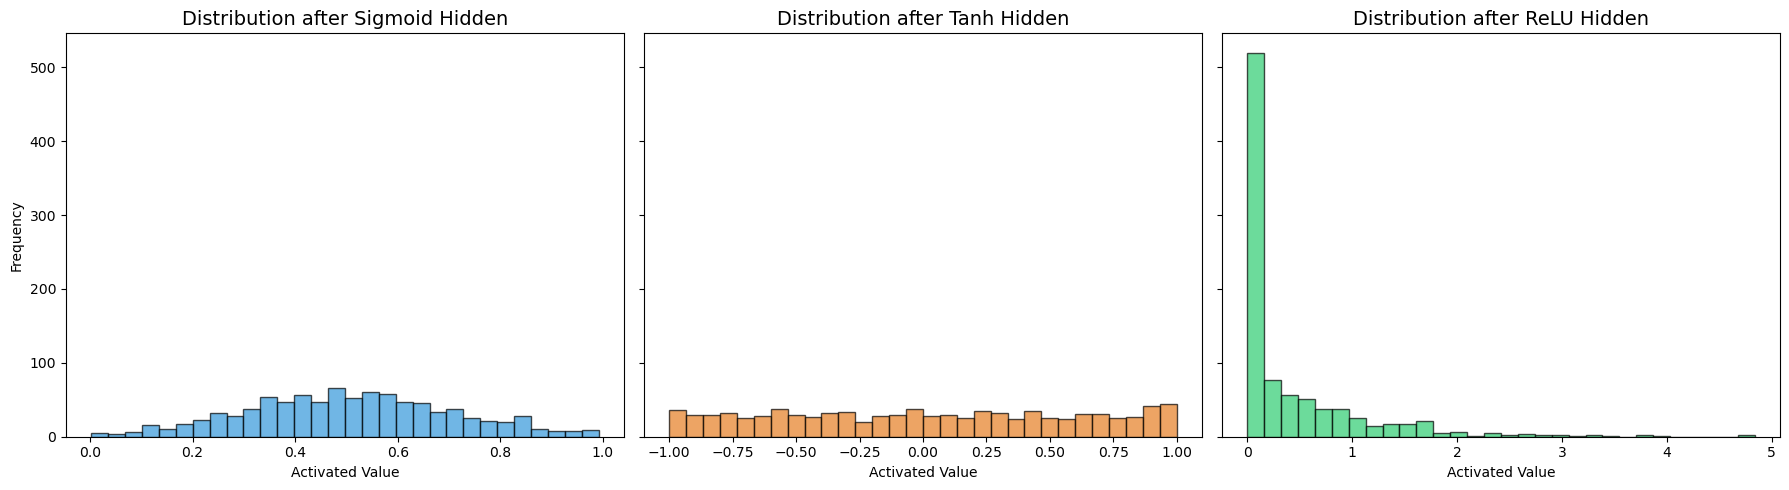

In [11]:
# Get the pre-activations (z1)
# We can use any of the models since fc1 is the same in all
model.eval()
with torch.no_grad():
    # z1 = X * W1 + b1
    z1 = model.fc1(X_test_tensor).numpy()

# Create the 1x3 Subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = ['Sigmoid Hidden', 'Tanh Hidden', 'ReLU Hidden']
activations = [torch.sigmoid, torch.tanh, torch.relu]
colors = ['#3498db', '#e67e22', '#2ecc71']

for i, ax in enumerate(axes):
    # Apply the specific activation to the same z1
    activated_values = activations[i](torch.from_numpy(z1)).numpy().flatten()
    
    ax.hist(activated_values, bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    ax.set_title(f"Distribution after {titles[i]}", fontsize=14)
    ax.set_xlabel("Activated Value")
    if i == 0:
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

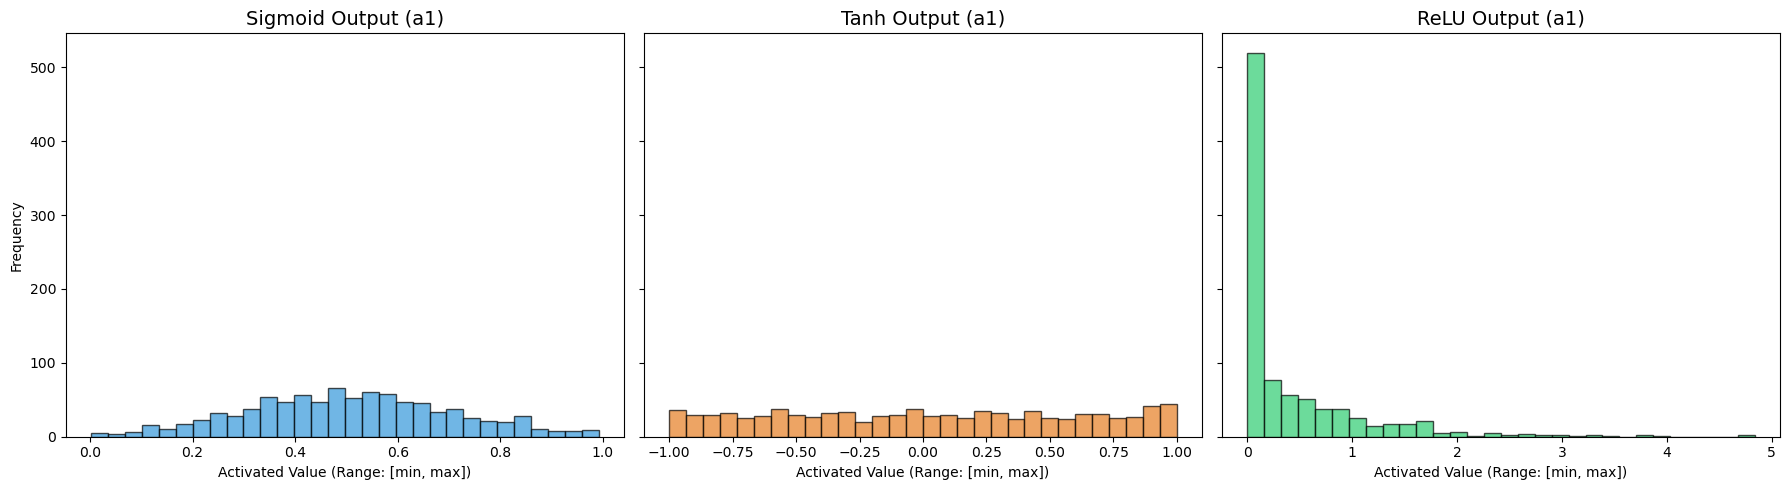

In [12]:
# Get the raw z1 pre-activation values
model.eval()
with torch.no_grad():
    z1 = model.fc1(X_test_tensor)

# Define the activation functions
activations = [torch.sigmoid, torch.tanh, torch.relu]
titles = ['Sigmoid Output (a1)', 'Tanh Output (a1)', 'ReLU Output (a1)']
colors = ['#3498db', '#e67e22', '#2ecc71']

# Create the 1x3 Subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ax in enumerate(axes):
    # Apply the activation to z1 to get 'a1'
    a1 = activations[i](z1).numpy().flatten()
    
    ax.hist(a1, bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    ax.set_title(titles[i], fontsize=14)
    ax.set_xlabel("Activated Value (Range: [min, max])")
    if i == 0:
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### For Sigmoid and Tanh, what fraction of the post-activation values fall in the saturated region (close to 0/1 for sigmoid, close to ±1 for tanh)?
For Sigmoid, the majority of the post-activation values form a bell curve centered around 0.5, but for Tanh, values are spread out between -1 and 1 uniformly

#### Looking at ReLU: roughly what fraction of the units are inactive (output exactly 0)?
Approximately 50% to 60% of the neurons are currently inactive. This is visually represented by the massive "tower" at the 0.0 mark in histogram

#### Based on these histograms, why might ReLU be the better default for hidden layers?
While the Sigmoid and Tanh histograms show values strictly "squashed" within narrow ranges (0 to 1 or -1 to 1), the ReLU output reaches values as high as 5.0. This prevents the "vanishing gradient" problem